# JENDL-5 Fe-56 MF33 MT2 Uncertainty Diagnostic

Investigate the large uncertainties observed in JENDL-5 Fe-56 elastic scattering
(MT=2) MF33 covariance data. MT2 is stored as an NC LTY=0 (derived) record,
so its covariance must be reconstructed via the bilinear sum rule from the
contributing partial MTs on resonance-reconstructed cross sections.

This notebook uses the new `kika.processing.resolve_derived_covariance`
pipeline, which delegates resonance reconstruction to NJOY `reconr`. The
previous in-Python `endf.reconstruct_xs()` path is not working correctly
and is no longer used here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kika.endf.read_endf import read_endf
from kika.processing import resolve_derived_covariance

JENDL5_PATH = r"C:\Users\Usuario\BaradDur\Dev\kika\files\endf\Fe56_jendl5_n.endf"
NJOY_EXE = r"C:\Users\Usuario\BaradDur\Codes\NJOY2016\build\njoy.exe"

endf = read_endf(JENDL5_PATH, mf_numbers=[2, 3, 33])

mf33 = endf.files.get(33)
print(f"MF33 MT sections: {sorted(mf33.sections.keys())}")

MF33 MT sections: [1, 2, 4, 16, 22, 28, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 102, 103, 104, 105, 106, 107, 111, 112, 115]


In [2]:
# Inspect MT2 subsections, LB types and the NC LTY=0 derivation record
mt2 = mf33.sections[2]
print(f"MT2 subsections: {len(mt2.subsections)}")
for i, sub in enumerate(mt2.subsections):
    print(f"\nSubsection {i}: MT1={sub.mt1}")
    for j, ni in enumerate(sub.ni_records):
        print(f"  NI[{j}]: LB={ni.lb}, NE={ni.ne}, LS={ni.ls}")
        if ni.lb == 5 and ni.matrix:
            print(f"    Matrix elements: {len(ni.matrix)}")
        if ni.lb in (1, 2) and ni.e_table_k:
            print(f"    E-table length: {len(ni.e_table_k)}")
    for j, nc in enumerate(sub.nc_records):
        print(f"  NC[{j}]: LTY={nc.lty}, NCI={nc.nci}")
        if nc.lty == 0:
            contribs = list(zip(nc.ci, [int(round(x)) for x in nc.xmti]))
            print(f"    Sum rule: Ïƒ(MT2) = " + " + ".join(
                f"{c:+g}Â·Ïƒ(MT{m})" for c, m in contribs
            ))
            print(f"    Energy range: [{nc.e1:.4e}, {nc.e2:.4e}] eV")

MT2 subsections: 1

Subsection 0: MT1=2
  NI[0]: LB=0, NE=3, LS=None
  NC[0]: LTY=0, NCI=54
    Sum rule: Ïƒ(MT2) = +1Â·Ïƒ(MT1) + -1Â·Ïƒ(MT16) + -1Â·Ïƒ(MT22) + -1Â·Ïƒ(MT28) + -1Â·Ïƒ(MT51) + -1Â·Ïƒ(MT52) + -1Â·Ïƒ(MT53) + -1Â·Ïƒ(MT54) + -1Â·Ïƒ(MT55) + -1Â·Ïƒ(MT56) + -1Â·Ïƒ(MT57) + -1Â·Ïƒ(MT58) + -1Â·Ïƒ(MT59) + -1Â·Ïƒ(MT60) + -1Â·Ïƒ(MT61) + -1Â·Ïƒ(MT62) + -1Â·Ïƒ(MT63) + -1Â·Ïƒ(MT64) + -1Â·Ïƒ(MT65) + -1Â·Ïƒ(MT66) + -1Â·Ïƒ(MT67) + -1Â·Ïƒ(MT68) + -1Â·Ïƒ(MT69) + -1Â·Ïƒ(MT70) + -1Â·Ïƒ(MT71) + -1Â·Ïƒ(MT72) + -1Â·Ïƒ(MT73) + -1Â·Ïƒ(MT74) + -1Â·Ïƒ(MT75) + -1Â·Ïƒ(MT76) + -1Â·Ïƒ(MT77) + -1Â·Ïƒ(MT78) + -1Â·Ïƒ(MT79) + -1Â·Ïƒ(MT80) + -1Â·Ïƒ(MT81) + -1Â·Ïƒ(MT82) + -1Â·Ïƒ(MT83) + -1Â·Ïƒ(MT84) + -1Â·Ïƒ(MT85) + -1Â·Ïƒ(MT86) + -1Â·Ïƒ(MT87) + -1Â·Ïƒ(MT88) + -1Â·Ïƒ(MT89) + -1Â·Ïƒ(MT90) + -1Â·Ïƒ(MT91) + -1Â·Ïƒ(MT102) + -1Â·Ïƒ(MT103) + -1Â·Ïƒ(MT104) + -1Â·Ïƒ(MT105) + -1Â·Ïƒ(MT106) + -1Â·Ïƒ(MT107) + -1Â·Ïƒ(MT111) + -1Â·Ïƒ(MT112) + -1Â·Ïƒ(MT115)
    Energy range: [1.0000e-05, 2.0000e+07] eV


In [3]:
# Resolve MT2 derived covariance end-to-end: NJOY reconr for pointwise Ïƒ,
# then the bilinear sum-rule contraction over the contributor MTs on their
# union MF33 grid.
#
# Pass the file path (not the pre-parsed `endf`) so the NJOY wrapper has a
# source tape to feed `reconr`.
xs_cov = resolve_derived_covariance(
    JENDL5_PATH,
    mt=2,
    njoy_executable=NJOY_EXE,
    tolerance=1e-3,
)

print(f"Number of matrices: {xs_cov.num_matrices}")
print(f"is_relative flags: {xs_cov.is_relative}")
print(f"Energy grids: {len(xs_cov.energy_grids)} grids")

for i, mat in enumerate(xs_cov.matrices):
    diag = np.diag(mat)
    is_rel = xs_cov.is_relative[i] if i < len(xs_cov.is_relative) else 'NOT SET'
    grid = xs_cov.energy_grids[i] if i < len(xs_cov.energy_grids) else None

    print(f"\nMatrix {i}: shape={mat.shape}, is_relative={is_rel}")
    if grid is not None:
        print(f"  Energy range: [{grid[0]:.4e}, {grid[-1]:.4e}] eV")
    print(f"  Diagonal range: [{diag.min():.4e}, {diag.max():.4e}]")
    print(f"  sqrt(diag) range: [{np.sqrt(np.maximum(diag, 0)).min():.4e}, {np.sqrt(np.maximum(diag, 0)).max():.4e}]")

    if is_rel is True or is_rel == 'NOT SET':
        unc_pct = np.sqrt(np.maximum(diag, 0)) * 100
        print(f"  As relative %: [{unc_pct.min():.2f}%, {unc_pct.max():.2f}%]")

    # Quick off-diagonal sanity â€” the NC LTY=0 rewrite must return a full
    # matrix, not just np.diag(...).
    off = mat - np.diag(diag)
    print(f"  Max |off-diagonal|: {np.abs(off).max():.4e}")

C:\Users\Usuario\BaradDur\Dev\kika\kika\endf\parsers\parse_endf.py:96: UserWarning: Skipping MF sections without parsers: [6, 8]. Only parsing: [1, 2, 3, 4, 33, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")
NJOY reconr ill-behaved threshold at tol=0.001; retrying at tol=0.002.
NJOY reconr required loosened tolerance 0.002 (requested 0.001).


Number of matrices: 1
is_relative flags: [True]
Energy grids: 1 grids

Matrix 0: shape=(115, 115), is_relative=True
  Energy range: [1.0000e-05, 2.0000e+08] eV
  Diagonal range: [0.0000e+00, 1.5176e-01]
  sqrt(diag) range: [0.0000e+00, 3.8956e-01]
  As relative %: [0.00%, 38.96%]
  Max |off-diagonal|: 2.4925e-02


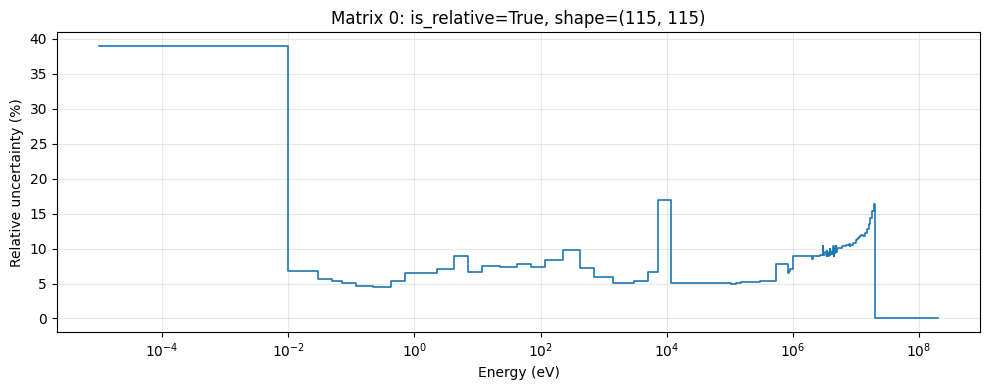

In [4]:
# Plot uncertainties per matrix, handling relative vs absolute correctly
n_mats = len(xs_cov.matrices)
fig, axes = plt.subplots(n_mats, 1, figsize=(10, 4 * max(n_mats, 1)), squeeze=False)

for i, mat in enumerate(xs_cov.matrices):
    ax = axes[i, 0]
    grid = np.array(xs_cov.energy_grids[i]) if i < len(xs_cov.energy_grids) else None
    if grid is None:
        continue

    diag = np.diag(mat)
    is_rel = xs_cov.is_relative[i] if i < len(xs_cov.is_relative) else True

    if is_rel:
        unc = np.sqrt(np.maximum(diag, 0)) * 100
        ylabel = 'Relative uncertainty (%)'
    else:
        unc = np.sqrt(np.maximum(diag, 0))
        ylabel = 'Absolute std dev (barns)'

    ax.step(grid, np.append(unc, unc[-1]), where='post', linewidth=1.2)
    ax.set_xscale('log')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Matrix {i}: is_relative={is_rel}, shape={mat.shape}')
    ax.set_xlabel('Energy (eV)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Verify uncertainty values at key energies
grid = np.array(xs_cov.energy_grids[0])
diag = np.diag(xs_cov.matrices[0])
unc_pct = np.sqrt(np.maximum(diag, 0)) * 100

print("Uncertainty at key energies:")
for e_query in [0.0253, 1.0, 1e3, 1e5, 1e6, 5e6, 1e7, 1.5e7, 2e7]:
    idx = np.searchsorted(grid, e_query) - 1
    if 0 <= idx < len(unc_pct):
        print(f"  {e_query:.4g} eV: {unc_pct[idx]:.2f}%")

print(f"\nMax uncertainty: {unc_pct.max():.2f}% at group {np.argmax(unc_pct)}")
positive = unc_pct[unc_pct > 0]
if positive.size:
    print(f"Median uncertainty: {np.median(positive):.2f}%")

Uncertainty at key energies:
  0.0253 eV: 6.73%
  1 eV: 6.52%
  1000 eV: 5.98%
  1e+05 eV: 5.01%
  1e+06 eV: 7.08%
  5e+06 eV: 9.58%
  1e+07 eV: 10.85%
  1.5e+07 eV: 12.28%
  2e+07 eV: 16.33%

Max uncertainty: 38.96% at group 0
Median uncertainty: 9.33%
